## miniGPT

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, dataloader

import numpy as np
import random 
import matplotlib as plt

import sys
sys.path.append("..")

from src.data import preprocess_text

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

Device: cuda


In [4]:
# Model Configration

block_size = 128
embedding_dim = 64
n_head = 8
n_layer = 4

dropout = 0.0
batch_size = 64

In [5]:
# Load Dataset

with open("../data/input.txt", "r") as file:
    text = file.read()

slice = int(0.1*len(text))
text = text[:slice]

print(f"Original length: {len(text)}")

text = preprocess_text(text)
print(f"Cleaned length: {len(text)}")

Original length: 111539
Cleaned length: 106823


In [6]:
# Vocabulary

chars = sorted(set(text))
vocab_size = len(chars)

print(f"Vocabulary size: {vocab_size}")
print(chars)

Vocabulary size: 29
['\n', ' ', '.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [7]:
# Encoder & Decoder

stoi = {char: i for i, char in enumerate(chars)}
itos = {i: char for i, char in enumerate(chars)}

def encode(text):
    return [stoi[c] for c in text]


def decode(ids):
    return "".join(itos[i] for i in ids)

In [8]:
sample = "hello world"

encoded = encode(sample)
decoded = decode(encoded)

print("Original :", sample)
print("Encoded  :", encoded)
print("Decoded  :", decoded)

Original : hello world
Encoded  : [10, 7, 14, 14, 17, 1, 25, 17, 20, 14, 6]
Decoded  : hello world


In [9]:
# Convert dataset into tensor

data = torch.tensor(encode(text), dtype=torch.long)

print(data.shape)
print(data.dtype)

torch.Size([106823])
torch.int64


In [10]:
# Train test split

split = int(0.9 * len(data))

train_data = data[:split]
test_data = data[split:]

print(f"Train characters: {len(train_data)}")
print(f"Test characters : {len(test_data)}")

Train characters: 96140
Test characters : 10683


In [11]:
from src.data import get_batch

X, Y = get_batch(
    train_data,
    batch_size,
    block_size,
    device
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: torch.Size([64, 128])
Y shape: torch.Size([64, 128])


In [12]:
from src.model import GPTEmbedding

embedding = GPTEmbedding(vocab_size=vocab_size, block_size=block_size,embedding_dim=embedding_dim).to(device)

x, y = get_batch(train_data, batch_size, block_size, device)

emb = embedding(x)

print("Input shape     :", x.shape)
print("Embedding shape :", emb.shape)

Input shape     : torch.Size([64, 128])
Embedding shape : torch.Size([64, 128, 64])


In [13]:
from src.model import MiniGPT

model = MiniGPT(
    vocab_size=vocab_size,
    block_size=block_size,
    embedding_dim=embedding_dim,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout
).to(device)

print(model)

MiniGPT(
  (embedding): GPTEmbedding(
    (token_embedding): Embedding(29, 64)
    (position_embedding): Embedding(128, 64)
  )
  (blocks): Sequential(
    (0): TransformerBlock(
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (attention): MultiHeadAttention(
        (heads): ModuleList(
          (0-7): 8 x Head(
            (query): Linear(in_features=64, out_features=8, bias=False)
            (key): Linear(in_features=64, out_features=8, bias=False)
            (value): Linear(in_features=64, out_features=8, bias=False)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (projection): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (feed_forward): FeedForward(
        (feed_forward): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): 

In [14]:
# Total parameters

from src.utils import count_parameters

summary = count_parameters(model)

print("\nTotal Parameters:", summary["total_parameters"])
print("Total Parameters (M):", summary["total_parameters_millions"])
print("Breakdown:", summary["breakdown"])

Total trainable parameters: 211,200
Total parameters in millions: 0.21M

---------------------------------------------------------------------------
embedding.token_embedding.weight                                  1,856
embedding.position_embedding.weight                               8,192
blocks.0.ln1.weight                                                  64
blocks.0.ln1.bias                                                    64
blocks.0.attention.heads.0.query.weight                             512
blocks.0.attention.heads.0.key.weight                               512
blocks.0.attention.heads.0.value.weight                             512
blocks.0.attention.heads.1.query.weight                             512
blocks.0.attention.heads.1.key.weight                               512
blocks.0.attention.heads.1.value.weight                             512
blocks.0.attention.heads.2.query.weight                             512
blocks.0.attention.heads.2.key.weight                      

In [15]:
X, Y = get_batch(train_data, batch_size, block_size, device)

logits = model(X)

print("X shape     :", X.shape)
print("Y shape     :", Y.shape)
print("Logits shape:", logits.shape)

X shape     : torch.Size([64, 128])
Y shape     : torch.Size([64, 128])
Logits shape: torch.Size([64, 128, 29])


In [16]:
# Weight Initialization 

from src.utils import initialize_weights

model.apply(initialize_weights)
print("Weight Initialized")

Weight Initialized


In [17]:
loss_fn = nn.CrossEntropyLoss()

B, T, C = logits.shape
loss = loss_fn(logits.view(B * T, C), Y.view(B * T))

print(f"Initial loss: {loss.item():.4f}")

Initial loss: 3.5044


In [18]:
# Optimizer

learning_rate = 2e-4
weight_decay = 0.01

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0002
    maximize: False
    weight_decay: 0.01
)


In [19]:
# Training Configrations

max_iters = 5000

eval_interval = 250
eval_iters = 100

best_val_loss = float("inf")

train_losses = []
val_losses = []

@torch.no_grad()
def loss_estimate(model, train_data, test_data):

    model.eval()

    results = {}

    for split_name, data_source in [("train", train_data), ("val", test_data)]:

        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            X, Y = get_batch(data_source, batch_size, block_size, device)
            logits = model(X)

            B, T, C = logits.shape

            loss = loss_fn(
                logits.view(B * T, C),
                Y.view(B * T)
            )
            losses[k] = loss.item()

        results[split_name] = losses.mean().item()

    model.train()

    return results

In [45]:
# Training

model.train()

for iteration in range(1, max_iters + 1):

    # Get a random batch
    X, Y = get_batch(train_data, batch_size, block_size, device)

    # Forward pass
    logits = model(X)
    B, T, C = logits.shape

    # Loss function
    loss = loss_fn(logits.view(B * T, C), Y.view(B * T))

    # Backpropogation
    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    # Parameter update
    optimizer.step()

    # Evaluation
    if iteration == 1 or iteration % eval_interval == 0:

        losses = loss_estimate(model, train_data, test_data)

        train_loss = losses["train"]
        val_loss = losses["val"]

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Iteration {iteration:5d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Save best model - saving each model which beats previous one along with overall best
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            # torch.save(model.state_dict(), f"../models/mini_gpt_best_val_loss_{val_loss:.2f}.pth")
            torch.save(model.state_dict(), f"../models/mini_gpt_best_221k_param.pth")

Iteration     1 | Train Loss: 3.2893 | Val Loss: 3.2886
Iteration   250 | Train Loss: 2.4433 | Val Loss: 2.4565
Iteration   500 | Train Loss: 2.3667 | Val Loss: 2.3854
Iteration   750 | Train Loss: 2.3235 | Val Loss: 2.3466
Iteration  1000 | Train Loss: 2.2880 | Val Loss: 2.3212
Iteration  1250 | Train Loss: 2.2672 | Val Loss: 2.3014
Iteration  1500 | Train Loss: 2.2538 | Val Loss: 2.2923
Iteration  1750 | Train Loss: 2.2522 | Val Loss: 2.2876
Iteration  2000 | Train Loss: 2.2352 | Val Loss: 2.2710
Iteration  2250 | Train Loss: 2.2241 | Val Loss: 2.2672
Iteration  2500 | Train Loss: 2.2280 | Val Loss: 2.2714
Iteration  2750 | Train Loss: 2.2135 | Val Loss: 2.2559
Iteration  3000 | Train Loss: 2.2114 | Val Loss: 2.2531
Iteration  3250 | Train Loss: 2.2089 | Val Loss: 2.2529
Iteration  3500 | Train Loss: 2.2060 | Val Loss: 2.2522
Iteration  3750 | Train Loss: 2.2025 | Val Loss: 2.2473
Iteration  4000 | Train Loss: 2.1955 | Val Loss: 2.2371
Iteration  4250 | Train Loss: 2.1964 | Val Loss:

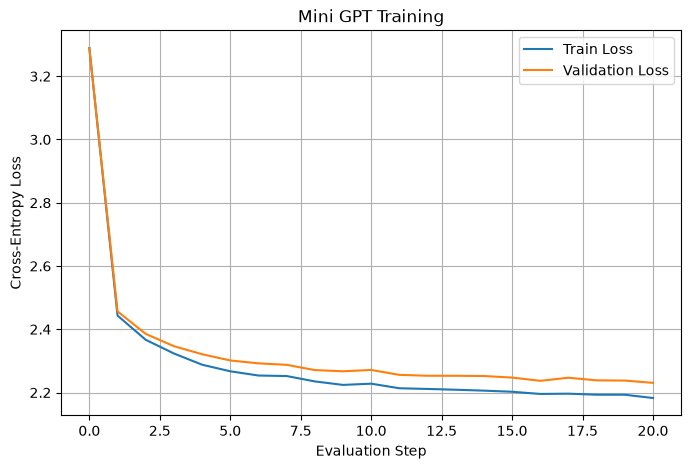

In [46]:
# Plotting
from src.utils import plot_loss_curve

plot_loss_curve(train_losses, val_losses)

In [20]:
# Load Best Model

model.load_state_dict(torch.load("../models/mini_gpt_best_221k_param.pth", map_location=device))

model = model.to(device)
model.eval()

print("Loaded")

Loaded


In [21]:
final_losses = loss_estimate(model, train_data, test_data)
print(f"Train Loss: {final_losses['train']:.4f}")
print(f"Validation Loss: {final_losses['val']:.4f}")

Train Loss: 2.1848
Validation Loss: 2.2287


In [22]:
# Perplexity

import math

train_perplexity = math.exp(final_losses["train"])
val_perplexity = math.exp(final_losses["val"])

print(f"Train Perplexity: {train_perplexity:.2f}")
print(f"Val Perplexity  : {val_perplexity:.2f}")

Train Perplexity: 8.89
Val Perplexity  : 9.29


In [23]:
# Response Generation

@torch.no_grad()
def generate(model, prompt, max_new_tokens, temperature=1.0, top_k=None):

    model.eval()

    # Encode prompt
    prompt = preprocess_text(prompt)
    idx = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        
        idx_recent = idx[:, -block_size:] # keep only most recent block_size tokens

        # Forward pass
        logits = model(idx_recent)

        # Take logits from the final position
        logits = logits[:, -1, :]

        # Apply temperature
        logits = logits / temperature

        # Option for top k sampling - consider only top k higher probable classes
        if top_k is not None:
            values, indices = torch.topk(logits, min(top_k, logits.size(-1)))
            filtered_logits = torch.full_like(logits, float("-inf"))
            filtered_logits.scatter_(1,indices, values)

            logits = filtered_logits

        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        # Append token to idx list
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())

In [24]:
prompt = "The night was quiet, and the wind carried"

print("\033[1m\n\nDefault\n\033[0m")
output = generate(model, prompt, max_new_tokens=400)
print(output)

print("\033[1m\n\nConservative\n\033[0m")
output = generate(model, prompt, max_new_tokens=400, temperature=0.5)
print(output)

print("\033[1m\n\nNormal\n\033[0m")
output = generate(model, prompt, max_new_tokens=400, temperature=1.0)
print(output)

print("\033[1m\n\nMore Random\n\033[0m")
output = generate(model, prompt, max_new_tokens=400, temperature=1.5)
print(output)

print("\033[1m\n\nTop K Sampling\n\033[0m")
output = generate(model, prompt, max_new_tokens=400, temperature=0.8, top_k=5)
print(output)



Default

the night was quiet and the wind carried
thaatos
rubldonpicens

corufobuius re ad heyou hirer hold iser malll topengey cale ouse he int th poreinnd e avijut theleaticendiengje
w s hous nal whe.eis thi here meshyasor ie ais y

waventhat cisond ld cang aye gricus otonseisnces heous rs nowinort y time axeneind

theno rie he coubes rn yhyout he wavisdh uly nswindw w me aks pastheesse asesseser.
sse
te heall utims me e thof somer eours d
ben


Conservative

the night was quiet and the wind carried thit o than sthis mat you the pe hit bee has the thourit th the the fo the the bustore ise he cout he be thit she i tome thand the this the lous wand he the the hei stous thot ou four we ous m owond tous the toul we the theno ith s wope me

thenethe iche t ourin thes he the wicou to t there of the athe an we tan yowe and an the knou whath the blit be to the
the won whathe u she outhad the thist t


Normal

the night was quiet and the wind carried s yopale

male
canius por mmusthei. th t

In [25]:
# Check pointing

checkpoint = {
    "model_state_dict": model.state_dict(),

    "vocab_size": vocab_size,
    "block_size": block_size,
    "embedding_dim": embedding_dim,
    "n_head": n_head,
    "n_layer": n_layer,
    "dropout": dropout,

    "stoi": stoi,
    "itos": itos
}

torch.save(checkpoint, "../models/mini_gpt_checkpoint_221k_param.pth")

print("Complete checkpoint saved.")

Complete checkpoint saved.


In [26]:
checkpoint = torch.load(
    "../models/mini_gpt_checkpoint_221k_param.pth",
    map_location=device
)

loaded_model = MiniGPT(
    vocab_size=checkpoint["vocab_size"],
    block_size=checkpoint["block_size"],
    embedding_dim=checkpoint["embedding_dim"],
    n_head=checkpoint["n_head"],
    n_layer=checkpoint["n_layer"],
    dropout=checkpoint["dropout"]
).to(device)

loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()

print("Checkpoint loaded successfully.")

Checkpoint loaded successfully.


Embedding shape: (29, 64)
PCA shape: (29, 2)
Explained variance: [0.18795946 0.09359562]
Total explained variance: 28.16%


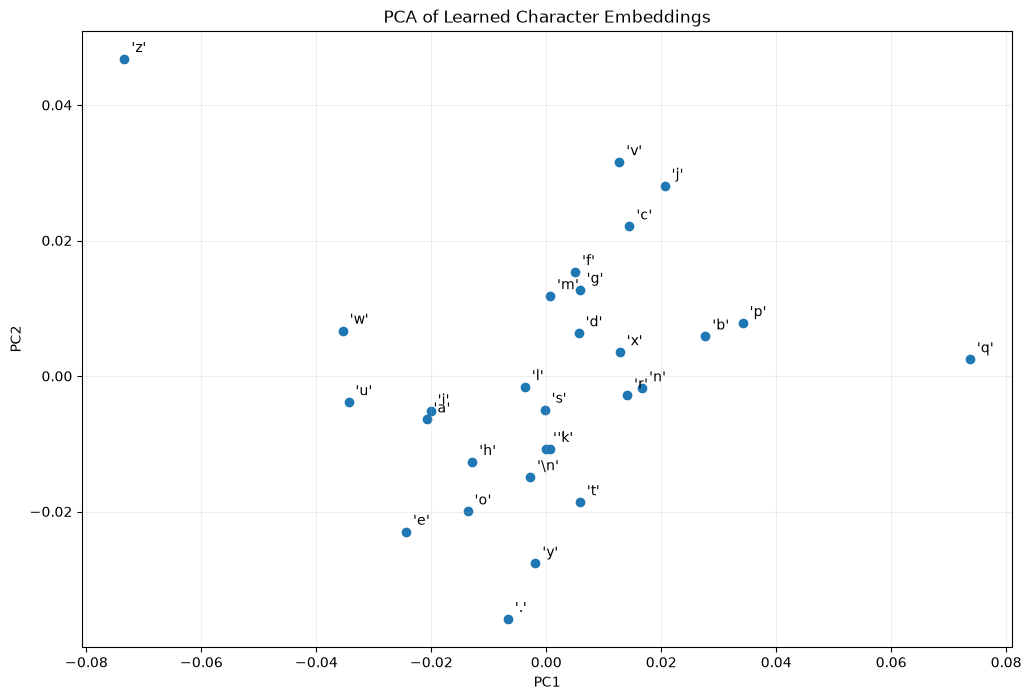

In [27]:
# PCA of Learned Character Embeddings

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Get learned embedding weights
embeddings = model.embedding.token_embedding.weight.detach().cpu().numpy()

print("Embedding shape:", embeddings.shape)

# PCA: 64D -> 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

print("PCA shape:", embeddings_2d.shape)
print(f"Explained variance: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# Plot
plt.figure(figsize=(12, 8))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1]
)

# Label each point with its character
for i, char in enumerate(chars):
    label = repr(char)   # makes '\n', ' ', etc. visible
    plt.annotate(
        label,
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Learned Character Embeddings")
plt.grid(alpha=0.2)
plt.show()